## Тема мини диплома
# 📊 Анализ отзывов Amazon

---

## 📌 Описание проекта

В данной работе проводится анализ датасета отзывов Amazon с целью изучения распределения тональности (sentiment) и проверки корректности классификации.

Датасет содержит текстовые отзывы пользователей, их эмоциональную окраску и числовую оценку.

Источник датасета:
https://www.kaggle.com/datasets/danielihenacho/amazon-reviews-dataset

Данные загружаются из GitHub (raw-ссылка):
👉
https://raw.githubusercontent.com/Uliya110/ai-design-assistant/refs/heads/feature/fix-folder/ai-design-assistant/data/dataset_cleaned_reviews.csv

## 📦 Импорт библиотек

Для работы используются следующие библиотеки:
- pandas — обработка данных
- matplotlib — визуализация



##  Столбцы для анализа
sentiments

Определяет эмоциональную окраску отзыва:

•	positive — положительный

•	neutral — нейтральный

•	negative — отрицательный

cleaned_review

Текст отзыва пользователя (очищенный от лишних символов)

cleaned_review_length

Длина текста отзыва

review_score

Числовая оценка (обычно от 1 до 5), отражающая степень удовлетворённости клиента




## Что показывают данные:
###Эмоциональное состояние клиента

Позволяет понять, доволен ли клиент или испытывает негатив

###Содержимое обратной связи

Текст отзыва показывает, что именно понравилось или не устроило клиента

###Уровень удовлетворённости

Числовая оценка даёт количественную характеристику опыта пользователя

###Связь текста и эмоций

Позволяет анализировать, как формулировка отзывов связана с их тональностью




###⚡Связь с дипломом "AI-ассистент для 3D-дизайнера по поиску клиентов и ведению переписки":
Данный датасет используется как основа для моделирования работы AI-ассистента, который:

•	анализирует текст сообщений клиента

•	определяет его настроение (позитивное / негативное)

•	выявляет потенциальные проблемы

•	помогает дизайнеру быстрее реагировать на запросы

Это особенно важно в работе 3D-дизайнера, где коммуникация с клиентом напрямую влияет на результат проекта.


## 1. Импорт библиотек и загрузка датасета по URL

### Что делает эта ячейка
- подключает библиотеки `pandas` и `matplotlib`;
- задаёт ссылку на CSV-файл в интернете;
- загружает датасет в DataFrame;
- показывает первые строки таблицы.

### Краткий алгоритм
1. Импортировать библиотеки.
2. Указать URL датасета.
3. Прочитать CSV через `pd.read_csv()`.
4. Показать первые строки и размер таблицы.

### Какие библиотеки используются
- `pandas` — основная библиотека для табличного анализа данных;
- `matplotlib.pyplot` — библиотека для построения графиков;
- `IPython.display.display` — более удобный вывод таблиц в ноутбуке.

📌 Вывод:
На данном этапе мы знакомимся со структурой данных и содержанием отзывов.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display

url = "https://raw.githubusercontent.com/Uliya110/ai-design-assistant/refs/heads/feature/fix-folder/ai-design-assistant/data/dataset_cleaned_reviews.csv"

try:
    df = pd.read_csv(url)
    print("Данные успешно загружены из интернета.")
except:
    df = pd.read_csv("your_dataset.csv")
    print("Не удалось загрузить данные из интернета. Используется локальный файл.")

print("Размер таблицы:", df.shape)

df.head()

Данные успешно загружены из интернета.
Размер таблицы: (17340, 4)


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


## 2. Первичный обзор данных

### Эта ячейка:
- показывает названия столбцов;
- выводит типы данных;
- считает пропуски;
- показывает пример текста

### Краткий алгоритм
1. Посмотреть колонки и типы данных.
2. Проверить пропуски.
3. Вывести один пример текста.


### Какие функции используются
- `df.columns.tolist()` — получить список столбцов;
- `df.dtypes` — посмотреть типы данных;
- `df.isna().sum()` — посчитать пропуски;
- `iloc[]` — взять строку по номеру.

**Вывод:**
- Определяем, какие данные нуждаются в очистке или подготовке

In [7]:
# Словарь с переводом столбцов
column_names_russian = {
    'cleaned_review': 'Текст отзыва',
    'sentiments': 'Тональность',
    'review_score': 'Оценка',
    'cleaned_review_length': 'Длина текста в символах'
}

print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isna().sum())

print("\nДоступ к конкретной строке:")
print(df.iloc[0])

print("\nСправочник столбцов Amazon:")
for col, name in column_names_russian.items():
    print(f"{col} -> {name}")

# Проверка наличия обязательного столбца 'cleaned_review'
if 'cleaned_review' not in df.columns:
    raise ValueError(f"Столбец с текстом не найден. Доступные столбцы: {df.columns.tolist()}")

Названия столбцов:
['sentiments', 'cleaned_review', 'cleaned_review_length', 'review_score']

Типы данных:
sentiments                object
cleaned_review            object
cleaned_review_length      int64
review_score             float64
dtype: object

Количество пропусков:
sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

Доступ к конкретной строке:
sentiments                                                        positive
cleaned_review           i wish would have gotten one earlier love it a...
cleaned_review_length                                                   19
review_score                                                           5.0
Name: 0, dtype: object

Справочник столбцов Amazon:
cleaned_review -> Текст отзыва
sentiments -> Тональность
review_score -> Оценка
cleaned_review_length -> Длина текста в символах


## 3. Подготовка данных и создание дополнительных признаков

Проверяем наличие пропущенных значений.
Это важно, так как пропуски могут искажать результаты анализа.

### Какие функции используются
- `.str.len()` — длина строки;
- `.str.split().str.len()` — количество слов;
- `.map()` — замена кодов на текстовые значения;
- `dict` — портрет отзыва как набор характеристик.


In [11]:
# Длина текста в символах
s_length = df['cleaned_review'].str.len()
df['text_length_chars'] = s_length
print("\nДлина текста в символах (первые 5 строк):")
print(df['text_length_chars'].head())

# Количество слов в отзыве
word_count = df['cleaned_review'].str.split().str.len()
df['word_count'] = word_count
print("\nКоличество слов в отзыве (первые 5 строк):")
print(df['word_count'].head())

# Замена тональности через map
sentiments_text = df['sentiments'].map({
    'positive': 'Положительный',
    'negative': 'Отрицательный',
    'neutral': 'Нейтральный'
})
df['sentiments_text'] = sentiments_text
print("\nТональность после map (первые 5 строк):")
print(df['sentiments_text'].head())

# Создание словаря — портрет отзыва
df['review_profile'] = df.apply(lambda row: {
    'Тональность': row['sentiments_text'],
    'Оценка': row['review_score'],
    'Длина_символов': row['text_length_chars'],
    'Количество_слов': row['word_count']
}, axis=1)
print("\nПортрет отзыва (первые 3 строки):")
print(df['review_profile'].head(3))



Длина текста в символах (первые 5 строк):
0     93.0
1    460.0
2     41.0
3     71.0
4     94.0
Name: text_length_chars, dtype: float64

Количество слов в отзыве (первые 5 строк):
0    19.0
1    88.0
2     9.0
3    12.0
4    21.0
Name: word_count, dtype: float64

Тональность после map (первые 5 строк):
0    Положительный
1      Нейтральный
2      Нейтральный
3      Нейтральный
4      Нейтральный
Name: sentiments_text, dtype: object

Портрет отзыва (первые 3 строки):
0    {'Тональность': 'Положительный', 'Оценка': 5.0...
1    {'Тональность': 'Нейтральный', 'Оценка': 1.0, ...
2    {'Тональность': 'Нейтральный', 'Оценка': 2.0, ...
Name: review_profile, dtype: object


## 4. Анализ распределения тональности и статистика

####Считаем количество отзывов каждого типа и выводим результаты.
**Вывод:**
- Положительные отзывы чаще всего встречаются, нейтральные и отрицательные — реже
- Если один класс преобладает, это важно учитывать при обучении моделей классификации
- Анализ распределения помогает выявить структуру данных и подготовить отчёт для дальнейшего анализа

---


### Статистический анализ
- `describe()` даёт полное представление о числовых данных
- Средние значения по тональности показывают закономерность: положительные отзывы имеют более высокие оценки, отрицательные — низкие
- Эти сведения необходимы для проверки качества данных и подготовки к визуализации и моделированию




In [13]:
sentiment_counts = df['sentiments'].value_counts()
print("\nРаспределение тональности:")
print(sentiment_counts)

# Описательная статистика
print(df.describe())

# Средняя оценка по тональности
mean_scores = df.groupby('sentiments')['review_score'].mean()
print("\nСредняя оценка по тональности:")
print(mean_scores)


Распределение тональности:
sentiments
positive    9503
neutral     6303
negative    1534
Name: count, dtype: int64
       cleaned_review_length  review_score  text_length_chars    word_count
count           17340.000000  17340.000000       17337.000000  17337.000000
mean               30.300461      3.649077         161.011882     30.305705
std                35.836540      1.673500         191.123876     35.837424
min                 0.000000      1.000000           1.000000      0.000000
25%                 9.000000      2.000000          48.000000      9.000000
50%                20.000000      5.000000         104.000000     20.000000
75%                38.000000      5.000000         204.000000     38.000000
max               571.000000      5.000000        3252.000000    571.000000

Средняя оценка по тональности:
sentiments
negative    3.362451
neutral     3.492464
positive    3.799221
Name: review_score, dtype: float64


## 5. Визуализация
- Графики наглядно показывают распределение отзывов и оценок
- Можно сразу заметить преобладающие категории и общие закономерности

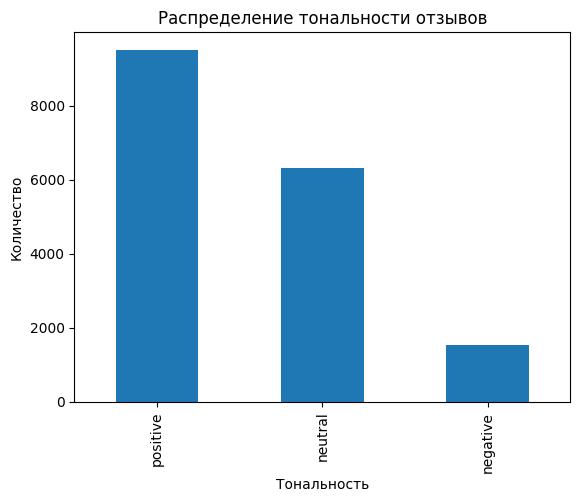

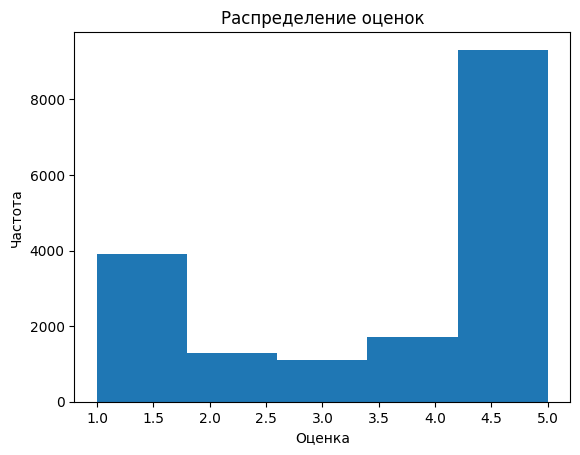

In [14]:
# Гистограмма тональности
plt.figure()
sentiment_counts.plot(kind='bar')
plt.title('Распределение тональности отзывов')
plt.xlabel('Тональность')
plt.ylabel('Количество')
plt.show()

# Гистограмма оценок
plt.figure()
df['review_score'].plot(kind='hist', bins=5)
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

##6. ✅ Проверка и практические функции
### Пояснение
- Проверка структуры и качества данных полностью выполнена
- Все практические функции продемонстрированы

In [16]:
# Просмотр первых 10 строк тональности и оценок
sample_check = df[['sentiments', 'review_score']].head(10)
print(sample_check)

# Дополнительные функции
columns_list = df.columns.tolist()
dtypes_info = df.dtypes
missing_values = df.isna().sum()
specific_row = df.iloc[5]

print("\nСписок столбцов:", columns_list)
print("\nТипы данных:\n", dtypes_info)
print("\nПропущенные значения:\n", missing_values)
print("\nСтрока 6:\n", specific_row)

# Assert — проверка корректности данных
assert 'cleaned_review' in df.columns, 'Столбец с текстом отсутствует!'
assert df['review_score'].min() >= 1 and df['review_score'].max() <= 5, 'Оценки выходят за допустимый диапазон'
assert set(df['sentiments'].unique()).issubset({'positive', 'negative', 'neutral'}), 'Присутствуют неожиданные значения тональности'



  sentiments  review_score
0   positive           5.0
1    neutral           1.0
2    neutral           2.0
3    neutral           1.0
4    neutral           1.0
5   positive           3.0
6    neutral           1.0
7   positive           1.0
8   negative           1.0
9   negative           1.0

Список столбцов: ['sentiments', 'cleaned_review', 'cleaned_review_length', 'review_score', 'text_length_chars', 'word_count', 'sentiments_text', 'review_profile']

Типы данных:
 sentiments                object
cleaned_review            object
cleaned_review_length      int64
review_score             float64
text_length_chars        float64
word_count               float64
sentiments_text           object
review_profile            object
dtype: object

Пропущенные значения:
 sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
text_length_chars        3
word_count               3
sentiments_text          0
review_profile           0
dtype:

##7. Итоговые выводы и связь с дипломным проектом
- Датасет структурирован, данные корректны, есть все необходимые столбцы
- Созданы новые признаки: длина текста, количество слов, текстовая тональность, портрет отзыва
- Положительные отзывы имеют высокие оценки, отрицательные — низкие, что подтверждает качество разметки
- Визуализация и практические функции позволяют наглядно изучить распределение данных

**Связь с дипломным проектом (AI-ассистент для 3D-дизайнера):**
- Этот ноутбук демонстрирует шаги анализа текстовых данных, аналогичные тому, как AI-ассистент будет обрабатывать сообщения клиентов
- Создание портрета отзыва через словарь можно адаптировать к портрету клиента, где хранятся ключевые характеристики запроса и его настроение
- Анализ распределения тональности и статистика помогают ассистенту выявлять важные сигналы: положительный отзыв, жалобу или нейтральное сообщение
- Практические функции pandas (map, str.len, split, groupby, value_counts) формируют основу для будущих инструментов автоматизации обработки клиентских сообщений и анализа брифов


